In [ ]:
# import libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import jupyter 
import openpyxl 

In [7]:
# load data 
df = pd.read_csv('../data/hotel_bookings.csv')

In [8]:
df.shape

(119390, 32)

In [9]:
#coloumns name and data types
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 119390 entries, 0 to 119389
Data columns (total 32 columns):
 #   Column                          Non-Null Count   Dtype  
---  ------                          --------------   -----  
 0   hotel                           119390 non-null  object 
 1   is_canceled                     119390 non-null  int64  
 2   lead_time                       119390 non-null  int64  
 3   arrival_date_year               119390 non-null  int64  
 4   arrival_date_month              119390 non-null  object 
 5   arrival_date_week_number        119390 non-null  int64  
 6   arrival_date_day_of_month       119390 non-null  int64  
 7   stays_in_weekend_nights         119390 non-null  int64  
 8   stays_in_week_nights            119390 non-null  int64  
 9   adults                          119390 non-null  int64  
 10  children                        119386 non-null  float64
 11  babies                          119390 non-null  int64  
 12  meal            

In [10]:
df.isnull().sum()

hotel                                  0
is_canceled                            0
lead_time                              0
arrival_date_year                      0
arrival_date_month                     0
arrival_date_week_number               0
arrival_date_day_of_month              0
stays_in_weekend_nights                0
stays_in_week_nights                   0
adults                                 0
children                               4
babies                                 0
meal                                   0
country                              488
market_segment                         0
distribution_channel                   0
is_repeated_guest                      0
previous_cancellations                 0
previous_bookings_not_canceled         0
reserved_room_type                     0
assigned_room_type                     0
booking_changes                        0
deposit_type                           0
agent                              16340
company         

In [11]:
df.head()

,hotel,is_canceled,lead_time,arrival_date_year,arrival_date_month,arrival_date_week_number,arrival_date_day_of_month,stays_in_weekend_nights,stays_in_week_nights,adults,...,deposit_type,agent,company,days_in_waiting_list,customer_type,adr,required_car_parking_spaces,total_of_special_requests,reservation_status,reservation_status_date
0,Resort Hotel,0,342,2015,July,27,1,0,0,2,...,No Deposit,NaN,NaN,0,Transient,0.0,0,0,Check-Out,2015-07-01
1,Resort Hotel,0,737,2015,July,27,1,0,0,2,...,No Deposit,NaN,NaN,0,Transient,0.0,0,0,Check-Out,2015-07-01
2,Resort Hotel,0,7,2015,July,27,1,0,1,1,...,No Deposit,NaN,NaN,0,Transient,75.0,0,0,Check-Out,2015-07-02
3,Resort Hotel,0,13,2015,July,27,1,0,1,1,...,No Deposit,304.0,NaN,0,Transient,75.0,0,0,Check-Out,2015-07-02
4,Resort Hotel,0,14,2015,July,27,1,0,2,2,...,No Deposit,240.0,NaN,0,Transient,98.0,0,1,Check-Out,2015-07-03


In [15]:
#describe the data
df['adr'].describe()
# df.describe()

count    119390.000000
mean        101.831122
std          50.535790
min          -6.380000
25%          69.290000
50%          94.575000
75%         126.000000
max        5400.000000
Name: adr, dtype: float64

In [16]:
# Remove rows where adr is negative or zero
df = df[df['adr'] > 0]

# Check
print(f"Rows remaining: {len(df)}")

Rows remaining: 117430


In [17]:
# Remove ADR outliers using IQR method
Q1 = df['adr'].quantile(0.25)
Q3 = df['adr'].quantile(0.75)
IQR = Q3 - Q1
upper_bound = Q3 + 1.5 * IQR

df = df[df['adr'] <= upper_bound]

print(f"Upper bound: {upper_bound:.2f}")
print(f"Rows remaining: {len(df)}")

Upper bound: 209.20
Rows remaining: 113380


In [20]:
# Create key metrics
df['total_nights'] = df['stays_in_weekend_nights'] + df['stays_in_week_nights']
df['revenue'] = df['adr'] * df['total_nights']

# Verify
df[['adr', 'total_nights', 'revenue']].head(10)

,adr,total_nights,revenue
2,75.0,1,75.0
3,75.0,1,75.0
4,98.0,2,196.0
5,98.0,2,196.0
6,107.0,2,214.0
7,103.0,2,206.0
8,82.0,3,246.0
9,105.5,3,316.5
10,123.0,4,492.0
11,145.0,4,580.0


In [24]:
df['is_canceled'].unique()

array([0, 1])

In [26]:
taux_occupation = (df['is_canceled'] == 0).sum() / len(df)
print(f"Taux d'occupation: {taux_occupation:.2%}")

Taux d'occupation: 62.57%


In [29]:
RevPAR = df['adr'].mean() * taux_occupation
print(f"RevPAR: {RevPAR:.2f}")

RevPAR: 61.60


In [30]:
# Export clean dataset
df.to_csv('../data/hotel_bookings_clean.csv', index=False)

In [31]:
# ADR by month
adr_by_month = df.groupby('arrival_date_month')['adr'].mean().round(2)
print(adr_by_month)

arrival_date_month
April         99.60
August       123.48
December      80.76
February      74.53
January       71.80
July         119.14
June         115.01
March         80.77
May          107.66
November      75.14
October       88.97
September    104.60
Name: adr, dtype: float64


In [32]:
# Define correct month order
month_order = ['January', 'February', 'March', 'April', 'May', 'June', 
               'July', 'August', 'September', 'October', 'November', 'December']

# Reindex
adr_by_month = adr_by_month.reindex(month_order)
print(adr_by_month)


arrival_date_month
January       71.80
February      74.53
March         80.77
April         99.60
May          107.66
June         115.01
July         119.14
August       123.48
September    104.60
October       88.97
November      75.14
December      80.76
Name: adr, dtype: float64


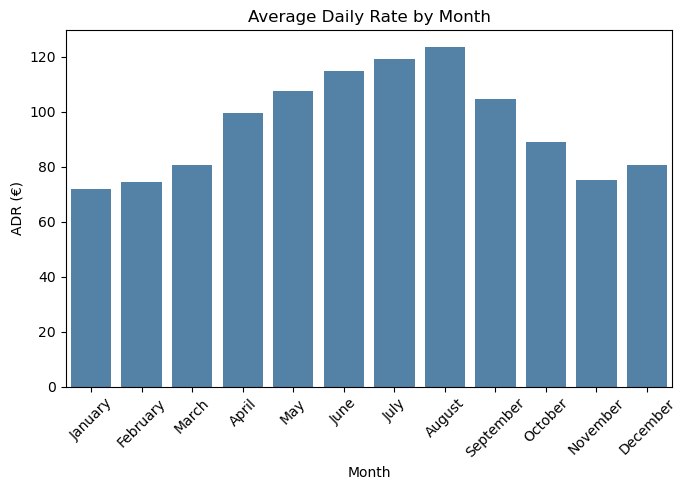

In [43]:
plt.figure(figsize=(7, 5))
sns.barplot(x=adr_by_month.index, 
            y=adr_by_month.values,
            color='steelblue')
plt.title('Average Daily Rate by Month')
plt.xlabel('Month')
plt.ylabel('ADR (€)')
plt.xticks(rotation=45)
plt.tight_layout()
plt.savefig('../exports/adr_by_month.png', bbox_inches='tight')
plt.show()

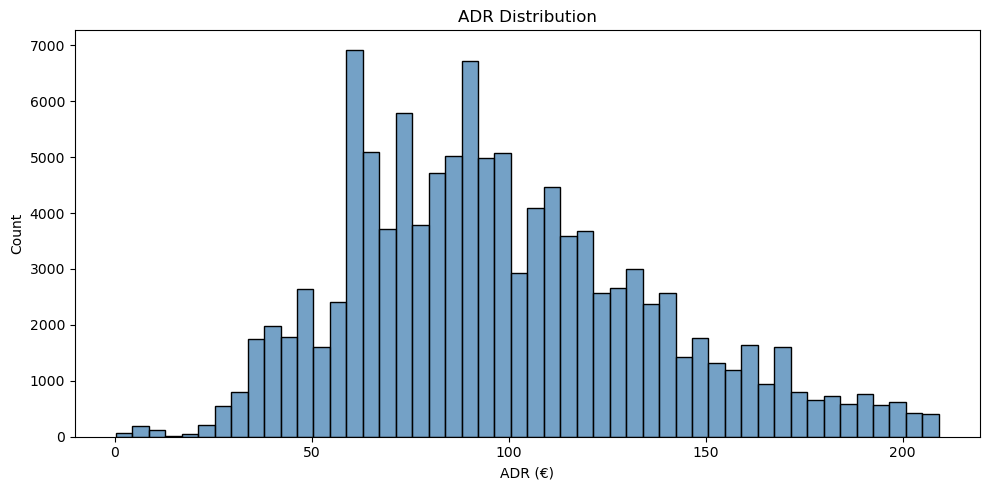

In [48]:
# ADR distribution
plt.figure(figsize=(10, 5))
sns.histplot(df['adr'], bins=50, color='steelblue')
plt.title('ADR Distribution')
plt.xlabel('ADR (€)')
plt.ylabel('Count')
plt.tight_layout()
plt.savefig('../exports/adr_distribution.png', bbox_inches='tight')
plt.show()

In [49]:
# Occupancy rate by month
occupancy_by_month = df.groupby('arrival_date_month')['is_canceled'].apply(
    lambda x: (x == 0).sum() / len(x) * 100
).reindex(month_order).round(2)

print(occupancy_by_month)

arrival_date_month
January      69.04
February     66.19
March        67.50
April        58.87
May          60.04
June         58.26
July         62.31
August       61.83
September    60.36
October      61.54
November     68.24
December     63.83
Name: is_canceled, dtype: float64


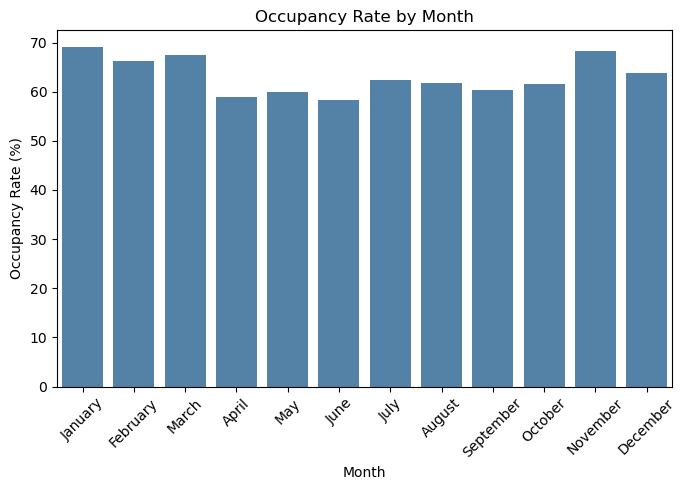

In [53]:
plt.figure(figsize=(7, 5))
sns.barplot(x=occupancy_by_month.index, 
            y=occupancy_by_month.values,
            color='steelblue')
plt.title('Occupancy Rate by Month')
plt.xlabel('Month')
plt.ylabel('Occupancy Rate (%)')
plt.xticks(rotation=45)
plt.tight_layout()
plt.savefig('../exports/occupancy_by_month.png', bbox_inches='tight')
plt.show()